# LF 06 · Comparison of the A2199 luminosity function with other samples

Fits a Schechter function (MCMC) to each binned LF, normalises every curve to the A2199 fit at M_r = −21.3, and compares A2199 with Coma, Virgo, the field (Blanton et al. 2005; Geller et al. 2012) and the TNG50 halo. Also writes the machine-readable table of the normalised LFs and plots the (α, M*) parameters of all samples.

**Inputs** (produced by notebooks 01–05 in this folder)
- `A2199_LF.csv`, `Coma_LF.csv`, `Virgo_LF.csv`, `Field_LF.csv`, `TNG50_Halo0_LF.csv`

**Outputs**
- `FIGURE/images/LF_normalized_comparison_thumbnail.png`
- `DATA/A2199_Machine_Readable_Table3.txt` – normalised LFs (Table 3 of the paper)

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy.units as u
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

  0%|          | 0/5000 [00:00<?, ?it/s]

  3%|▎         | 138/5000 [00:00<00:03, 1374.52it/s]

  6%|▌         | 276/5000 [00:00<00:03, 1349.10it/s]

  8%|▊         | 411/5000 [00:00<00:03, 1341.88it/s]

 11%|█         | 549/5000 [00:00<00:03, 1355.74it/s]

...

 89%|████████▉ | 4443/5000 [00:03<00:00, 1493.92it/s]

 92%|█████████▏| 4593/5000 [00:03<00:00, 1489.40it/s]

 95%|█████████▍| 4745/5000 [00:03<00:00, 1495.81it/s]

 98%|█████████▊| 4895/5000 [00:03<00:00, 1493.01it/s]

100%|██████████| 5000/5000 [00:03<00:00, 1471.03it/s]

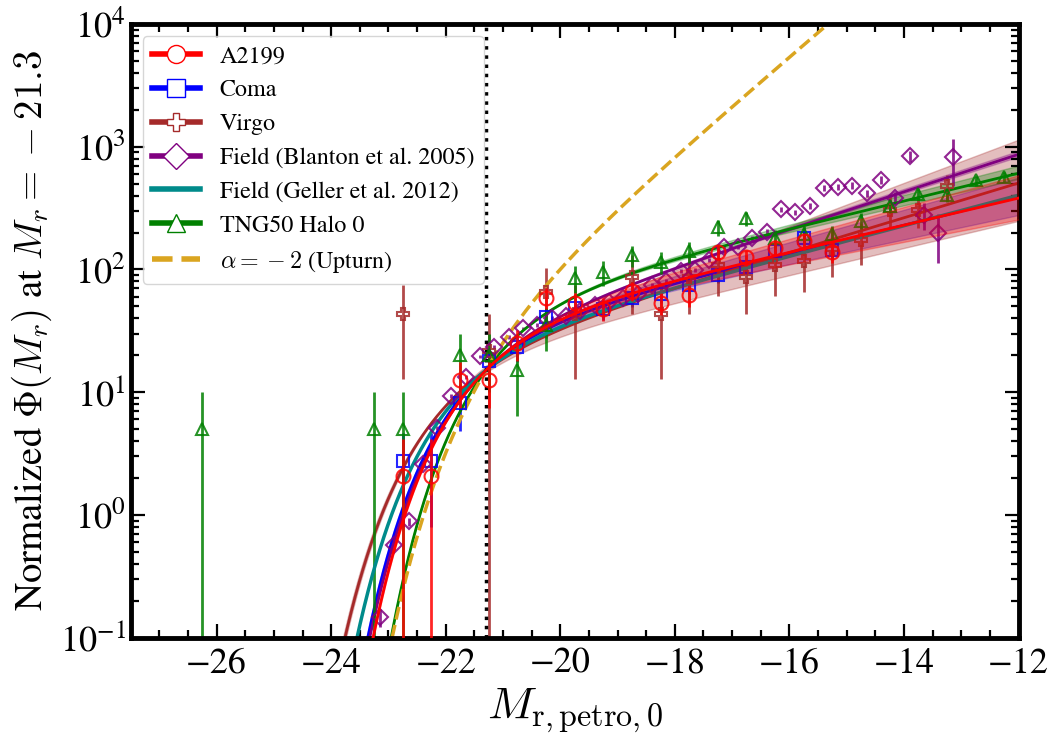

In [2]:
import emcee
from matplotlib.lines import Line2D

# ---- Binned luminosity functions from notebooks 01-05 ----
df_dict = {
    'A2199': pd.read_csv('A2199_LF.csv'),
    'Coma': pd.read_csv('Coma_LF.csv'),
    'TNG50 Halo 0': pd.read_csv('TNG50_Halo0_LF.csv'),
    'Field': pd.read_csv('Field_LF.csv'),
    'Virgo': pd.read_csv('Virgo_LF.csv')
}

# ---- Schechter function and MCMC fit ----
def schechter_1D_LF(M, phi_0, M_star, alpha):
    """Schechter function in magnitude space."""
    exponent = 10 ** (0.4 * (M_star - M))
    return phi_0 * exponent ** (1 + alpha) * np.exp(-exponent)

def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_LF(M, phi_0, M_star, alpha)
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1000 and -25 < M_star < -15 and -3.5 < alpha < 0.5:     # flat priors
        return 0.0
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

def fit_schechter_mcmc(x, y, yerr, nwalkers=50, nsteps=5000):
    """Return ((phi_0, M*, alpha) as 16/50/84 percentiles, flat samples)."""
    ndim = 3
    initial = np.array([1.0, -20.0, -1.0])
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
    sampler.run_mcmc(pos, nsteps, progress=True)
    samples = sampler.get_chain(discard=1000, thin=15, flat=True)
    phi_0 = np.percentile(samples[:, 0], [16, 50, 84])
    M_star = np.percentile(samples[:, 1], [16, 50, 84])
    alpha = np.percentile(samples[:, 2], [16, 50, 84])
    return (phi_0, M_star, alpha), samples

# Multiplicative offsets applied to each LF before fitting, so that all samples
# have phi_0 of the same order (the curves are re-normalised below anyway)
y_shifts = {
    'A2199': 5.0,
    'Coma': 1.0 * 1.05 * 1.5,
    'TNG50 Halo 0': 10.0 * 1.3,
    'Field': 2000.0 * 1.03 * 2,
    'Virgo': 1.0 * 1.4125,
}

# ---- Fit every sample ----
fit_results = {}
x_model = np.linspace(-27.5, 0, 8000)

for label, df in df_dict.items():
    x = df['M_r'].values
    y = df['Phi'].values * y_shifts[label]
    yerr = df['Phi_err'].values * y_shifts[label]
    (phi0_vals, mstar_vals, alpha_vals), _ = fit_schechter_mcmc(x, y, yerr)
    phi_0_med = phi0_vals[1]
    M_star_med = mstar_vals[1]
    alpha_med = alpha_vals[1]
    y_model = schechter_1D_LF(x_model, phi_0_med, M_star_med, alpha_med)
    y_model_lo = schechter_1D_LF(x_model, phi_0_med, M_star_med, alpha_vals[0])     # alpha 16th percentile
    y_model_hi = schechter_1D_LF(x_model, phi_0_med, M_star_med, alpha_vals[2])     # alpha 84th percentile
    fit_results[label] = {
        'x': x, 'y': y, 'yerr': yerr,
        'phi0': phi0_vals, 'Mstar': mstar_vals, 'alpha': alpha_vals,
        'y_model': y_model, 'y_model_lo': y_model_lo, 'y_model_hi': y_model_hi
    }

# ---- Plot styles ----
colors = {'A2199': 'red', 'Coma': 'blue', 'TNG50 Halo 0': 'green', 'Field': 'purple', 'Virgo': 'brown'}
markers = {'A2199': 'o', 'Coma': 's', 'TNG50 Halo 0': '^', 'Field': 'D', 'Virgo': 'P'}
plot_order = ['Coma', 'Virgo', 'Field', 'TNG50 Halo 0']     # A2199 is drawn last, on top

# ---- Normalised luminosity functions ----
fig, ax = plt.subplots(figsize=(11, 8))

x_norm = -21.30                                                        # normalisation magnitude
y_norm_target = np.interp(x_norm, x_model, fit_results['A2199']['y_model'])

# Other samples, scaled to the A2199 fit at x_norm
for label in plot_order:
    result = fit_results[label]
    y_at_norm = np.interp(x_norm, x_model, result['y_model'])
    scale_factor = y_norm_target / y_at_norm if y_at_norm > 0 else 1.0
    y_scaled = result['y'] * scale_factor
    yerr_scaled = result['yerr'] * scale_factor
    y_model_scaled = result['y_model'] * scale_factor
    y_model_lo_scaled = result['y_model_lo'] * scale_factor
    y_model_hi_scaled = result['y_model_hi'] * scale_factor
    ax.plot(x_model, y_model_scaled, linestyle='-', lw=2, color=colors[label])
    ax.fill_between(x_model, y_model_lo_scaled, y_model_hi_scaled, color=colors[label], alpha=0.3)
    ax.errorbar(result['x'], y_scaled, yerr=yerr_scaled, fmt=markers[label], color=colors[label],
                markerfacecolor='none', markeredgewidth=1.5, capsize=0, alpha=0.85, markersize=8)

# Reference curves, normalised at the same point
# (1) Schechter function with an upturn slope alpha = -2
y_ref_unscaled = schechter_1D_LF(x_model, 36.0, -21.3, -2.0)
y_ref_at_norm = np.interp(x_norm, x_model, y_ref_unscaled)
ref_scale_factor = y_norm_target / y_ref_at_norm
ax.plot(x_model, y_ref_unscaled * ref_scale_factor, ls='--', color='goldenrod', lw=2.5)

# (2) Field LF of Geller et al. (2012)
y_geller_unscaled = schechter_1D_LF(x_model, 140, -21.80, -1.31)
y_geller_at_norm = np.interp(x_norm, x_model, y_geller_unscaled)
geller_scale_factor = y_norm_target / y_geller_at_norm
ax.plot(x_model, y_geller_unscaled * geller_scale_factor, ls='-', color='darkcyan', lw=2.5)

# A2199 on top
result = fit_results['A2199']
ax.plot(x_model, result['y_model'], linestyle='-', lw=2, color=colors['A2199'], zorder=10)
ax.fill_between(x_model, result['y_model_lo'], result['y_model_hi'], color=colors['A2199'], alpha=0.3, zorder=10)
ax.errorbar(result['x'], result['y'], yerr=result['yerr'], fmt=markers['A2199'], color=colors['A2199'],
            markerfacecolor='none', markeredgewidth=1.5, capsize=0, alpha=0.85, markersize=10, zorder=10)

ax.set_yscale('log')
ax.set_xlim(-27.5, -12)
ax.set_ylim(0.1, 10000)
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=33)
ax.set_ylabel(r'Normalized $\Phi(M_r)$ at $M_r = -21.3$', fontsize=28)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=26)
ax.axvline(x_norm, color='black', linestyle=':', lw=2.5)     # normalisation point

custom_lines = [
    Line2D([0], [0], color=colors['A2199'], marker=markers['A2199'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color=colors['Coma'], marker=markers['Coma'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color=colors['Virgo'], marker=markers['Virgo'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color=colors['Field'], marker=markers['Field'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color='darkcyan', linestyle='-', linewidth=4),
    Line2D([0], [0], color=colors['TNG50 Halo 0'], marker=markers['TNG50 Halo 0'], ls='-', lw=4, ms=13, mfc='white'),
    Line2D([0], [0], color='goldenrod', linestyle='--', linewidth=4)
]
legend_labels = [
    'A2199',
    'Coma',
    'Virgo',
    'Field (Blanton et al. 2005)',
    'Field (Geller et al. 2012)',
    'TNG50 Halo 0',
    r'$\alpha = -2$ (Upturn)'
]
ax.legend(custom_lines, legend_labels, loc='upper left', fontsize=17.3)

plt.tight_layout()
plt.savefig('../../FIGURE/images/LF_normalized_comparison_thumbnail.png', bbox_inches='tight', dpi=100)
plt.show()

In [3]:
# ============================================================================
# Machine-readable table of the normalised luminosity functions (Table 3)
# ============================================================================
records = []
for sample_name, result in fit_results.items():
    for x, y, yerr in zip(result['x'], result['y'], result['yerr']):
        records.append({'Sample': sample_name, 'M_r': x, 'Phi': y, 'Phi_err': yerr})
df_all = pd.DataFrame(records)

header_txt = """
Title: A redshift survey of the nearby galaxy cluster Abell 2199 : No
upturn of the faint-end slope of galaxy luminosity function

Authors: Park J-I., Song H., Hwang H.S.
Table: Normalized Luminosity Function of A2199 and other samples

================================================================================
Byte-by-byte Description of file: v57n2p249_Table3.txt
--------------------------------------------------------------------------------
  Bytes  Format    Units             Label      Explanations
--------------------------------------------------------------------------------
   1-  1  I1       ---               Sample     Sample ID (1)
   3-  8  F6.2     mag               M_r        Absolute magnitude (2)
  10 -14  F5.1     h3Mpc-3mag-1      Phi        Luminosity function value (3)
  16- 20  F5.1     h3Mpc-3mag-1      Phi_err    Uncertainty in Phi (4)
--------------------------------------------------------------------------------
Note (1):
    Sample ID mapping:
      1 = A2199 (This study)
      2 = Coma (Kang et al. 2025) [2025ApJS..278...51K]
      3 = Virgo (Ferrarese et al. 2020) [2020ApJ...890..128F]
      4 = Field (Blanton et al. 2005) [2005ApJ...631..208B]
      5 = TNG50 Halo 0 (This study)

Note (2):
    Absolute magnitude is calculated based on the LambdaCDM cosmology
    with H0 = 70 km/s/Mpc, Omega_m = 0.3, and Omega_Lambda = 0.7.

Note (3):
    Phi and Phi_err are in comoving number density units: [h³ Mpc⁻³ mag⁻¹]
    Phi values are normalized to the luminosity function of A2199 at M_r = -21.3, which is the characteristic magnitude of the Schechter fit. While the other cluster luminosity functions are not in absolute units, they are scaled accordingly for comparison.

Note (4):
    Uncertainties in Phi are estimated from the Poisson statistics.
--------------------------------------------------------------------------------
"""

# Sample IDs in the order of the table notes; any extra sample is appended
desired_order = ["A2199", "Coma", "Virgo", "Field", "TNG50 Halo 0"]
present_labels = list(pd.unique(df_all['Sample']))
ordered_labels = [s for s in desired_order if s in present_labels] + \
                 [s for s in present_labels if s not in desired_order]
sample_mapping = {name: i + 1 for i, name in enumerate(ordered_labels)}

df_all['Sample_ID'] = df_all['Sample'].map(sample_mapping)
df_all_sorted = df_all.sort_values(['Sample_ID', 'M_r']).reset_index(drop=True)

output_path = '../../DATA/A2199_Machine_Readable_Table3.txt'

# Column widths from the formatted values
m_r_width = max(df_all_sorted['M_r'].apply(lambda x: f"{x:.2f}").map(len))
phi_width = max(df_all_sorted['Phi'].apply(lambda x: f"{x:.1f}").map(len))
phierr_width = max(df_all_sorted['Phi_err'].apply(lambda x: f"{x:.1f}").map(len))

with open(output_path, 'w') as f:
    f.write(header_txt.strip() + '\n\n')
    for _, row in df_all_sorted.iterrows():
        sample_id = row['Sample_ID']
        m_r_str = f"{row['M_r']:.2f}".rjust(m_r_width)
        phi_str = f"{row['Phi']:.1f}".rjust(phi_width)
        phierr_str = f"{row['Phi_err']:.1f}".rjust(phierr_width)
        f.write(f"{sample_id:1d} {m_r_str} {phi_str} {phierr_str}\n")

print("Sample-to-ID Mapping:")
for name in ordered_labels:
    print(f"  {sample_mapping[name]} = {name}")

Sample-to-ID Mapping:
  1 = A2199
  2 = Coma
  3 = Virgo
  4 = Field
  5 = TNG50 Halo 0


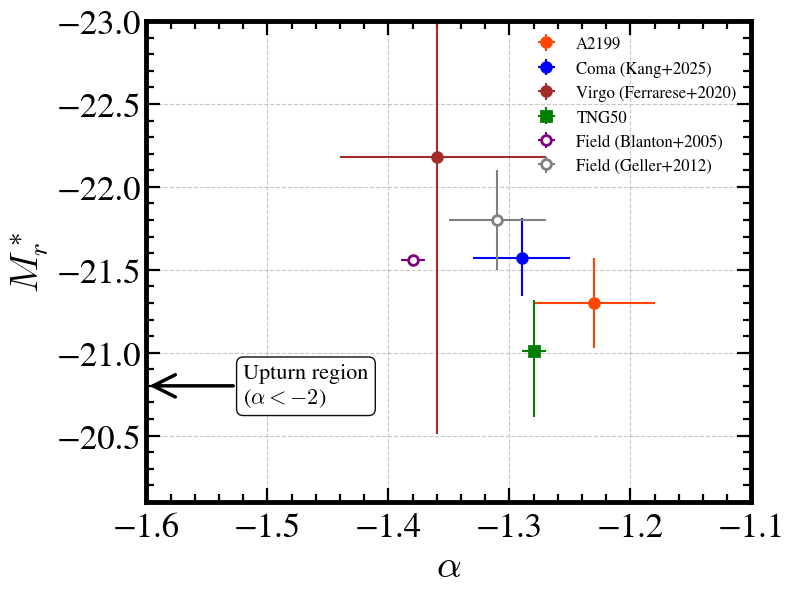

In [4]:
# ============================================================================
# Schechter parameters (alpha, M*) of all samples
# ============================================================================
# Values as quoted in the paper (Table of Schechter parameters); the A2199,
# Coma, Virgo and TNG50 values come from the MCMC fits of notebooks 01-04.
fit_data = [
    {'label': 'A2199', 'alpha': -1.23, 'alpha_err': [0.05, 0.05], 'M_star': -21.30, 'M_star_err': [0.27, 0.27]},
    {'label': 'Coma (Kang+2025)', 'alpha': -1.29, 'alpha_err': [0.04, 0.04], 'M_star': -21.57, 'M_star_err': [0.24, 0.23]},
    {'label': 'Virgo (Ferrarese+2020)', 'alpha': -1.36, 'alpha_err': [0.08, 0.09], 'M_star': -22.18, 'M_star_err': [2.16, 1.67]},
    {'label': 'TNG50', 'alpha': -1.28, 'alpha_err': [0.01, 0.01], 'M_star': -21.01, 'M_star_err': [0.31, 0.40]},
    {'label': 'Field (Blanton+2005)', 'alpha': -1.38, 'alpha_err': [0.01, 0.01], 'M_star': -21.56, 'M_star_err': [0.01, 0.01]},
    {'label': 'Field (Geller+2012)', 'alpha': -1.31, 'alpha_err': [0.04, 0.04], 'M_star': -21.80, 'M_star_err': [0.30, 0.30]},
]

custom_styles = {
    'A2199':                    {'marker': 'o', 'color': 'orangered', 'fill': True},
    'Coma (Kang+2025)':         {'marker': 'o', 'color': 'blue', 'fill': True},
    'Virgo (Ferrarese+2020)':   {'marker': 'o', 'color': 'brown', 'fill': True},
    'TNG50':                    {'marker': 's', 'color': 'green', 'fill': True},
    'Field (Blanton+2005)':     {'marker': 'o', 'color': 'purple', 'fill': False},
    'Field (Geller+2012)':      {'marker': 'o', 'color': 'gray', 'fill': False},
}

fig, ax = plt.subplots(figsize=(8.5, 6.5))

for result in fit_data:
    label = result['label']
    style = custom_styles[label]
    ax.errorbar(result['alpha'], result['M_star'],
                xerr=[[result['alpha_err'][0]], [result['alpha_err'][1]]],
                yerr=[[result['M_star_err'][0]], [result['M_star_err'][1]]],
                fmt=style['marker'],
                color=style['color'],
                markersize=7,
                markerfacecolor=style['color'] if style['fill'] else 'white',
                markeredgecolor=style['color'],
                markeredgewidth=2,
                lw=1.5,
                capsize=0,
                label=label)

ax.annotate(r'Upturn region' + '\n' + r'($\alpha < -2$)',
            xy=(-1.6, -20.8), xytext=(-1.52, -20.8),
            fontsize=16, ha='left', va='center',
            arrowprops=dict(arrowstyle="->", color='black', mutation_scale=40, linewidth=2.5),
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.95),
            color='black')

ax.set_xlabel(r'$\alpha$', fontsize=28)
ax.set_ylabel(r'$M^*_r$', fontsize=28)
ax.set_xlim(-1.6, -1.1)
ax.set_ylim(-23, -20.1)
ax.invert_yaxis()
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()